# 2. EDA

Análisis exploratorio ejecutado sobre la tabla samples de dati_campagna_venditti.m. Describe procedencia, tamaño, calidad, carga de primera falla, geometría, relaciones y redundancias antes del modelado.

**Alcance:** análisis descriptivo. No se ajustan modelos y una correlación no se interpreta como causalidad física.

In [1]:
from pathlib import Path
import json, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
warnings.filterwarnings("ignore",category=RuntimeWarning)
pd.set_option("display.max_columns",30)
pd.set_option("display.float_format",lambda x:f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi":110,"axes.titlesize":11})
ROOT=Path.cwd()
RUN="20261003T015928287717Z"
TABLE=ROOT/"data"/"processed"/RUN/"model_table.csv"
REPORT=ROOT/"data"/"processed"/RUN/"data_quality_report.json"
report=json.loads(REPORT.read_text(encoding="utf-8"))
df=pd.read_csv(TABLE)
full=pd.read_csv(ROOT/report["input_file"])
target=report["roles"]["target"]
predictors=report["roles"]["predictors"]
identifier=report["roles"]["identifiers"][0]
units=report["schema"]["predictor_units"]
print("Tabla:",TABLE.relative_to(ROOT))
print("Target:",target,"[N]")

Tabla: data\processed\20261003T015928287717Z\model_table.csv
Target: First_Failure_Load_N [N]


## 1. Procedencia, tamaño y completitud

Cada fila es un caso experimental. La curaduría conserva el identificador, diez descriptores geométricos y la primera falla. El target no se imputa. Las variables posensayo se excluyen para evitar fuga de información.

In [2]:
manifest=report["ingestion_manifest"]
display(pd.DataFrame({
"Elemento":["Fuente","SHA-256","Ingesta","Curaduría","Casos fuente","Columnas fuente","Casos con target","Predictores"],
"Valor":[manifest["source_file"],manifest["sha256"],manifest["run_id"],report["run_id"],len(full),full.shape[1],len(df),len(predictors)]
}).style.hide(axis="index"))
display(pd.DataFrame({
"Control":["Duplicados exactos","Target faltante","Identificadores repetidos","Predictores con variación"],
"Casos":[int(full.duplicated().sum()),int(full[target].isna().sum()),int(df[identifier].duplicated().sum()),int((df[predictors].nunique()>1).sum())]
}).style.hide(axis="index"))
print("Exclusión:",report["excluded_records"])
display(df.head())

Elemento,Valor
Fuente,data/raw/dati_campagna_venditti.m
SHA-256,3d82f876bb8ec652184707235aa4df1dfb4b1a6615551f78fe0e0662a6723f0c
Ingesta,20261003T015928118917Z
Curaduría,20261003T015928287717Z
Casos fuente,27
Columnas fuente,20
Casos con target,26
Predictores,10


Control,Casos
Duplicados exactos,0
Target faltante,1
Identificadores repetidos,0
Predictores con variación,9


Exclusión: [{'source_record': 2, 'reason': 'missing_target'}]


,__source_record,Case_n,n_cells_Y,Fiber_height,Fiber_base,Fiber_total_length,Fiber_total_volume,Pivot_height,Pivot_radius,Pivot_total_number,Pivot_total_volume,Sample_total_volume,First_Failure_Load_N
0,1,1,4.000,1.000,2.400,"2,685.820","6,435.300",1.000,0.500,113.000,88.710,"6,249.740",47.550
1,3,3,4.000,1.400,1.710,"2,685.820","6,435.300",1.000,0.500,113.000,88.710,"6,122.210",88.500
2,4,4,4.000,1.000,2.390,"2,685.820","6,417.560",1.200,0.500,113.000,106.450,"6,240.200",86.450
3,5,5,4.000,1.200,1.990,"2,685.820","6,417.560",1.200,0.500,113.000,106.450,"6,170.230",59.680
4,6,6,4.000,1.400,1.710,"2,685.820","6,417.560",1.200,0.500,113.000,106.450,"6,139.960",63.050


,faltantes,porcentaje
residual_Displacement_6cycle_60mm,7,25.926
First_Failure_Load_N,1,3.704
Ultimate_Load,1,3.704
residual_Displacement_1cycle_10mm,1,3.704
Maximum_Displacement,1,3.704
residual_Displacement_2cycle_20mm,1,3.704
residual_Displacement_3cycle_30mm,1,3.704
residual_Displacement_4cycle_40mm,1,3.704
residual_Displacement_5cycle_50mm,1,3.704


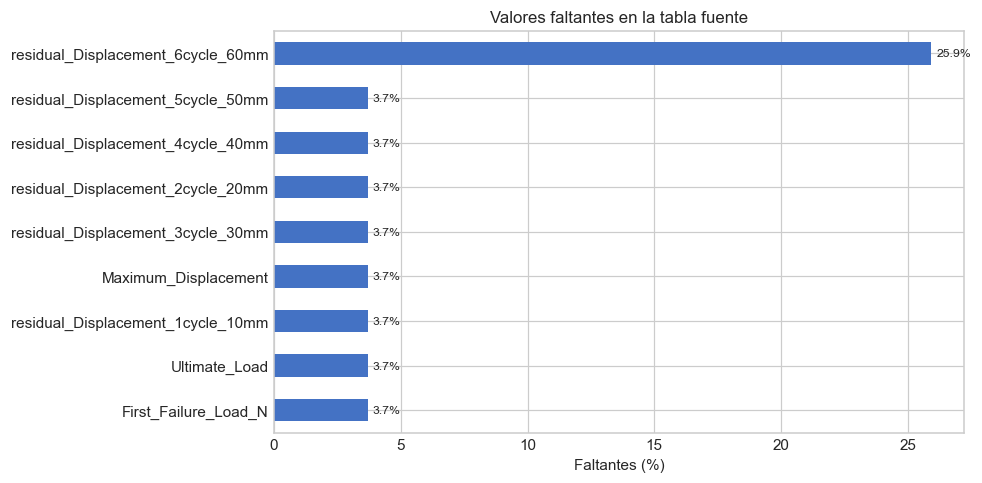

In [3]:
missing=(full.isna().sum().rename("faltantes").to_frame()
.assign(porcentaje=lambda x:100*x["faltantes"]/len(full)).query("faltantes>0").sort_values("faltantes",ascending=False))
display(missing)
ax=missing["porcentaje"].sort_values().plot(kind="barh",figsize=(9,4.5),color="#4472C4")
ax.set(title="Valores faltantes en la tabla fuente",xlabel="Faltantes (%)",ylabel="")
for p in ax.patches: ax.text(p.get_width()+.2,p.get_y()+p.get_height()/2,f"{p.get_width():.1f}%",va="center",fontsize=8)
plt.tight_layout();plt.show()

El caso 2 no tiene primera falla ni las principales respuestas posensayo. El sexto ciclo tiene más faltantes; debe verificarse si esos ensayos no llegaron a dicho ciclo.

## 2. Variable objetivo

First_Failure_Load_N es la fuerza del primer evento localizado de rotura, expresada en newtons. No equivale automáticamente a la carga máxima.

,Carga [N]
n,26.000
media,126.118
desv_estándar,59.912
mínimo,47.550
P25,78.395
mediana,101.890
P75,196.882
máximo,215.520


Regla 1.5×IQR: -99.34–374.61 N; casos señalados=0


,resultado
0,Ninguno


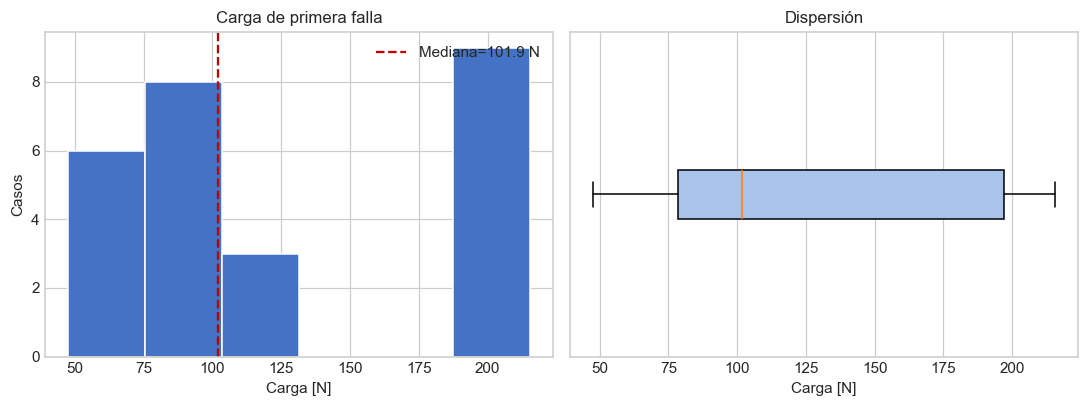

In [4]:
display(df[target].describe().rename({"count":"n","mean":"media","std":"desv_estándar","min":"mínimo","25%":"P25","50%":"mediana","75%":"P75","max":"máximo"}).to_frame("Carga [N]"))
q1,q3=df[target].quantile([.25,.75]);iqr=q3-q1;lo,hi=q1-1.5*iqr,q3+1.5*iqr
flags=df.loc[(df[target]<lo)|(df[target]>hi),[identifier,target]]
print(f"Regla 1.5×IQR: {lo:.2f}–{hi:.2f} N; casos señalados={len(flags)}")
display(flags if len(flags) else pd.DataFrame({"resultado":["Ninguno"]}))
fig,ax=plt.subplots(1,2,figsize=(10,3.8))
ax[0].hist(df[target],bins="auto",color="#4472C4",edgecolor="white")
ax[0].axvline(df[target].median(),color="#C00000",ls="--",label=f"Mediana={df[target].median():.1f} N")
ax[0].set(title="Carga de primera falla",xlabel="Carga [N]",ylabel="Casos");ax[0].legend()
ax[1].boxplot(df[target],vert=False,patch_artist=True,boxprops={"facecolor":"#A9C4EB"})
ax[1].set(title="Dispersión",xlabel="Carga [N]",yticks=[])
plt.tight_layout();plt.show()

## 3. Número de celdas

La comparación por n_cells_Y es descriptiva. Una diferencia no prueba causalidad porque otras dimensiones pueden cambiar simultáneamente.

,n_cells_Y,n,media_N,mediana_N,desviacion_N,minimo_N,maximo_N
0,4.000,8,68.984,67.120,13.910,47.550,88.500
1,5.000,9,99.379,100.770,11.935,75.710,114.300
2,6.000,9,203.644,205.340,8.654,191.390,215.520


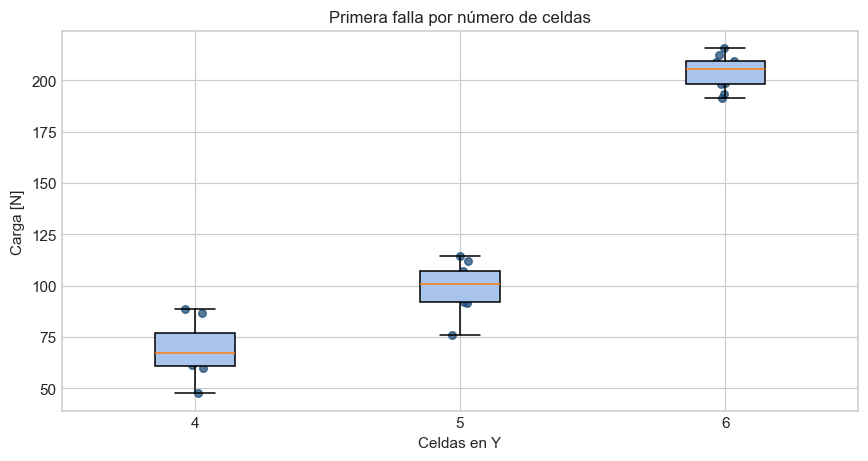

In [5]:
bycells=df.groupby("n_cells_Y")[target].agg(n="count",media_N="mean",mediana_N="median",desviacion_N="std",minimo_N="min",maximo_N="max").reset_index()
display(bycells)
vals=[g[target].to_numpy() for _,g in df.groupby("n_cells_Y")]
labels=[str(int(x)) for x in sorted(df["n_cells_Y"].unique())]
fig,ax=plt.subplots(figsize=(8,4.3))
ax.boxplot(vals,tick_labels=labels,patch_artist=True,boxprops={"facecolor":"#A9C4EB"})
rng=np.random.default_rng(42)
for pos,v in enumerate(vals,1):ax.scatter(pos+rng.normal(0,.035,len(v)),v,color="#1F4E79",s=24,alpha=.75)
ax.set(title="Primera falla por número de celdas",xlabel="Celdas en Y",ylabel="Carga [N]")
plt.tight_layout();plt.show()

## 4. Características geométricas

Se revisan rangos, valores únicos y variación. Una constante no explica diferencias entre casos. Pocos niveles indican un diseño discreto y evidencia limitada.

,unidad,n_válidos,n_únicos,mínimo,mediana,máximo,desv_estándar
predictor,,,,,,,
n_cells_Y,conteo,26,3,4.000,5.000,6.000,0.824
Fiber_height,mm,26,3,1.000,1.200,1.400,0.170
Fiber_base,mm,26,15,1.410,1.690,2.400,0.311
Fiber_total_length,mm,26,3,"2,685.820","3,178.560","3,725.650",428.907
Fiber_total_volume,mm^3,26,9,"6,259.110","6,362.930","6,435.300",57.677
Pivot_height,mm,26,3,1.000,1.200,1.400,0.165
Pivot_radius,mm,26,1,0.500,0.500,0.500,0.000
Pivot_total_number,conteo,26,3,113.000,171.000,241.000,52.897
Pivot_total_volume,mm^3,26,9,88.710,161.080,264.900,57.677


Constantes: ['Pivot_radius']


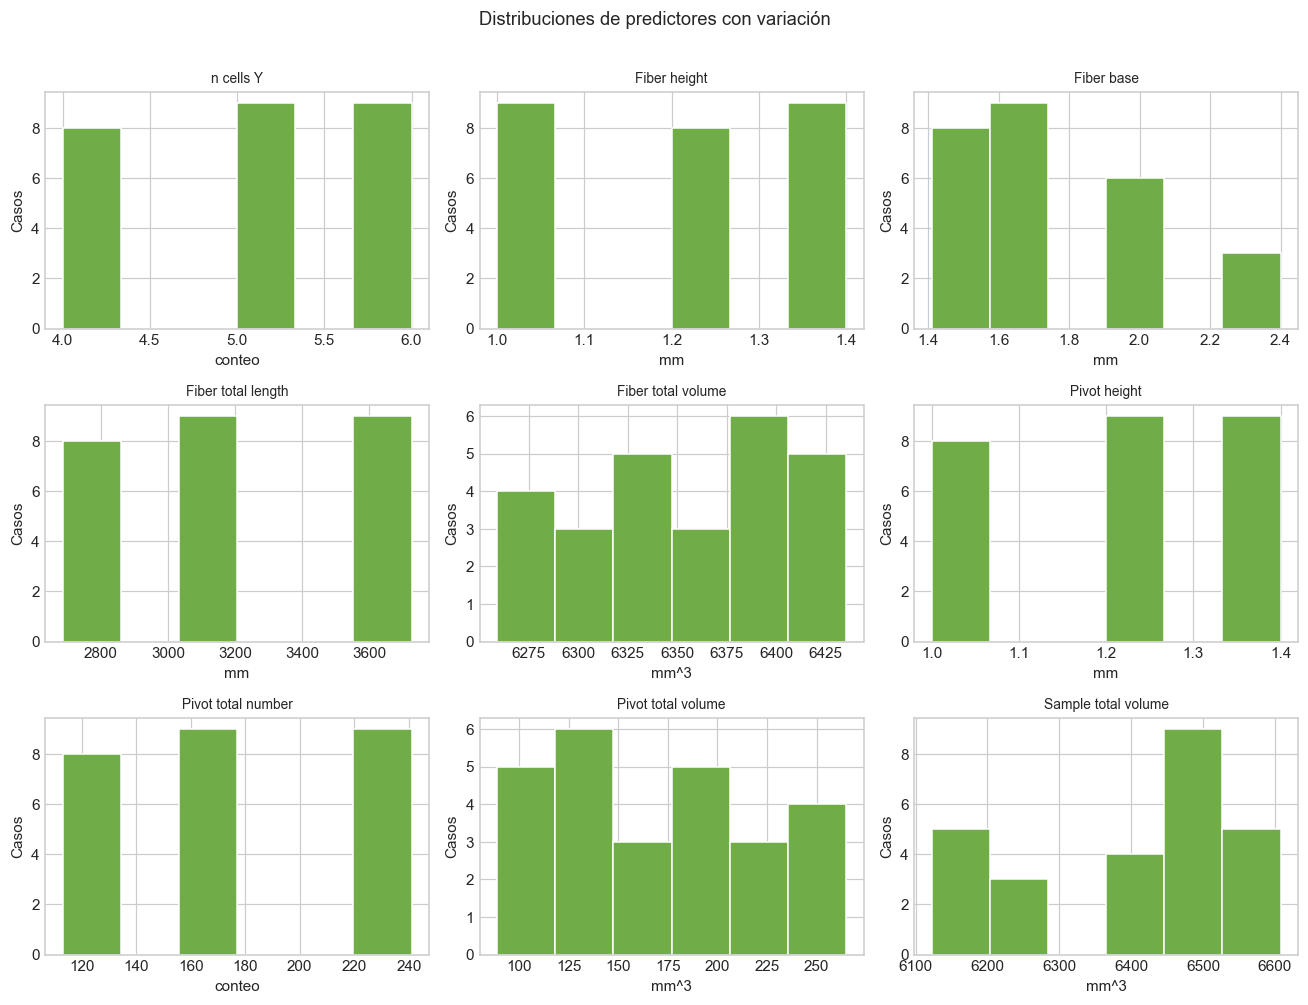

In [6]:
fs=pd.DataFrame({
"unidad":[units.get(x,"") for x in predictors],"n_válidos":[df[x].notna().sum() for x in predictors],
"n_únicos":[df[x].nunique() for x in predictors],"mínimo":[df[x].min() for x in predictors],
"mediana":[df[x].median() for x in predictors],"máximo":[df[x].max() for x in predictors],
"desv_estándar":[df[x].std() for x in predictors]},index=predictors)
fs.index.name="predictor";display(fs)
varying=[x for x in predictors if df[x].nunique()>1]
print("Constantes:",[x for x in predictors if x not in varying])
fig,axes=plt.subplots(3,3,figsize=(12,9))
for ax,col in zip(axes.flat,varying):
 ax.hist(df[col],bins="auto",color="#70AD47",edgecolor="white");ax.set_title(col.replace("_"," "),fontsize=9);ax.set_xlabel(units.get(col,""));ax.set_ylabel("Casos")
for ax in axes.flat[len(varying):]:ax.axis("off")
fig.suptitle("Distribuciones de predictores con variación",y=1.01);plt.tight_layout();plt.show()

## 5. Relaciones con la respuesta

Los diagramas muestran asociaciones, niveles discretos y puntos influyentes; no miden desempeño predictivo fuera de muestra.

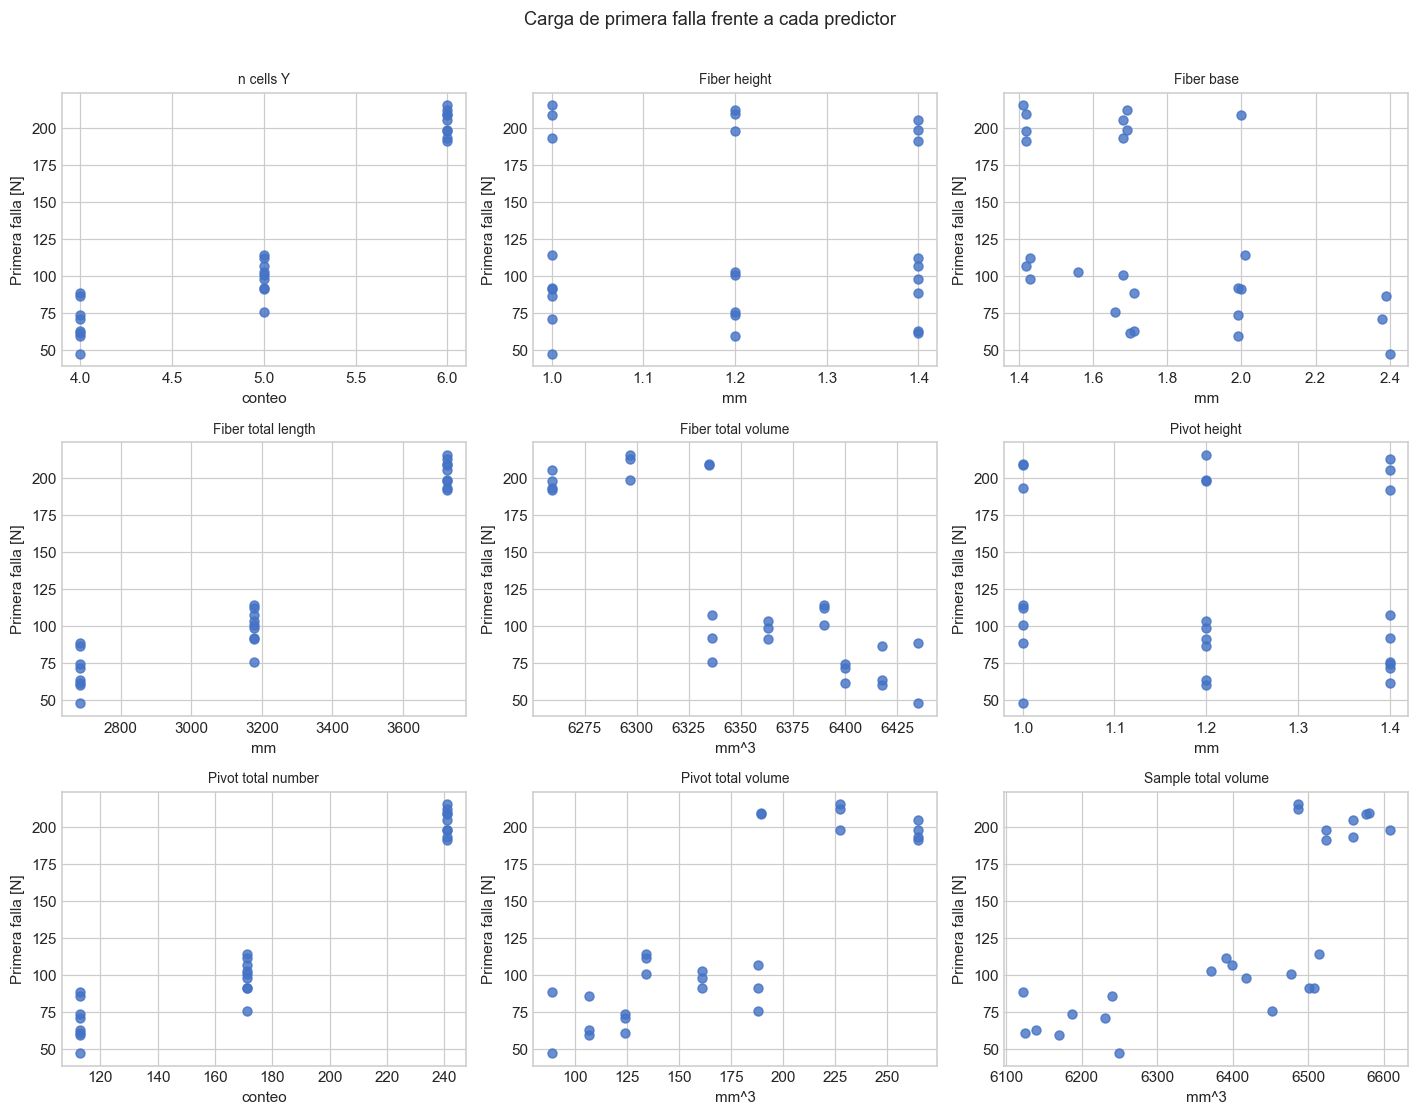

In [7]:
fig,axes=plt.subplots(3,3,figsize=(13,10))
for ax,col in zip(axes.flat,varying):
 ax.scatter(df[col],df[target],color="#4472C4",alpha=.8,s=34);ax.set_title(col.replace("_"," "),fontsize=9);ax.set_xlabel(units.get(col,""));ax.set_ylabel("Primera falla [N]")
for ax in axes.flat[len(varying):]:ax.axis("off")
fig.suptitle("Carga de primera falla frente a cada predictor",y=1.01);plt.tight_layout();plt.show()

## 6. Correlaciones y redundancia

Se usa Spearman por el tamaño pequeño y los niveles discretos. Una asociación alta puede aparecer porque dos variables derivan de la misma geometría. No demuestra causalidad ni capacidad predictiva.

,rho_Spearman
n_cells_Y,0.931
Fiber_total_length,0.931
Pivot_total_number,0.931
Pivot_total_volume,0.828
Fiber_total_volume,-0.828
Sample_total_volume,0.799
Fiber_base,-0.552
Pivot_height,-0.148
Fiber_height,0.000


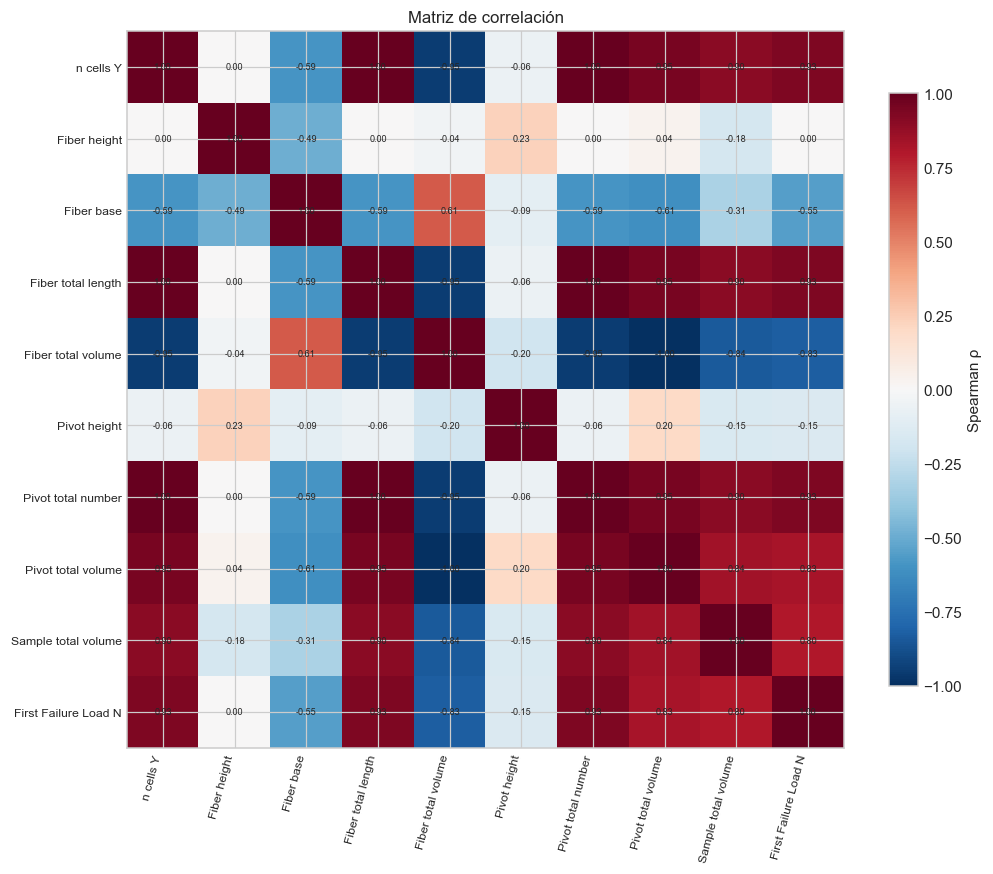

,predictor_1,predictor_2,rho
0,n_cells_Y,Fiber_total_length,1.000
2,n_cells_Y,Pivot_total_number,1.000
6,Fiber_total_length,Pivot_total_number,1.000
10,Fiber_total_volume,Pivot_total_volume,-1.000
1,n_cells_Y,Fiber_total_volume,-0.949
11,Pivot_total_number,Pivot_total_volume,0.949
3,n_cells_Y,Pivot_total_volume,0.949
7,Fiber_total_length,Pivot_total_volume,0.949
5,Fiber_total_length,Fiber_total_volume,-0.949
9,Fiber_total_volume,Pivot_total_number,-0.949


In [8]:
cols=varying+[target];corr=df[cols].corr(method="spearman")
targetcorr=corr[target].drop(target).sort_values(key=lambda s:s.abs(),ascending=False).rename("rho_Spearman").to_frame()
display(targetcorr)
fig,ax=plt.subplots(figsize=(9.5,8));im=ax.imshow(corr,vmin=-1,vmax=1,cmap="RdBu_r")
ax.set_xticks(range(len(corr)),[x.replace("_"," ") for x in corr.columns],rotation=75,ha="right",fontsize=8)
ax.set_yticks(range(len(corr)),[x.replace("_"," ") for x in corr.index],fontsize=8)
for i in range(len(corr)):
 for j in range(len(corr)):ax.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=6)
fig.colorbar(im,ax=ax,label="Spearman ρ",shrink=.8);ax.set_title("Matriz de correlación");plt.tight_layout();plt.show()
pairs=[];fc=df[varying].corr(method="spearman")
for i,a in enumerate(varying):
 for b in varying[i+1:]:
  if abs(fc.loc[a,b])>=.90:pairs.append({"predictor_1":a,"predictor_2":b,"rho":fc.loc[a,b]})
pairs=pd.DataFrame(pairs)
if len(pairs):pairs=pairs.sort_values("rho",key=lambda s:s.abs(),ascending=False)
display(pairs)

## 7. Controles físicos y fuga de información

Se comprueba positividad y se contrasta primera falla con Ultimate_Load solo para revisar su semántica. Si “carga última” significara máximo global, cualquier contradicción exigiría consultar la definición original.

In [9]:
checks=pd.DataFrame({"Control":["Geometrías o conteos <= 0","Primera falla <= 0","Primera falla > Ultimate_Load","Ultimate_Load faltante","Sexto ciclo faltante"],
"Casos":[int((df[predictors]<=0).any(axis=1).sum()),int((df[target]<=0).sum()),int((full[target]>full["Ultimate_Load"]).sum()),int(full["Ultimate_Load"].isna().sum()),int(full["residual_Displacement_6cycle_60mm"].isna().sum())]})
display(checks.style.hide(axis="index"))
print("Variables posensayo excluidas:",", ".join(report["unselected_columns"]))

Control,Casos
Geometrías o conteos <= 0,0
Primera falla <= 0,0
Primera falla > Ultimate_Load,17
Ultimate_Load faltante,1
Sexto ciclo faltante,7


Variables posensayo excluidas: Ultimate_Load, Maximum_Displacement, residual_Displacement_1cycle_10mm, residual_Displacement_2cycle_20mm, residual_Displacement_3cycle_30mm, residual_Displacement_4cycle_40mm, residual_Displacement_5cycle_50mm, residual_Displacement_6cycle_60mm


## 8. Hallazgos calculados

In [10]:
top=targetcorr.index[0];rho=targetcorr.iloc[0,0];ratio=len(df)/len(varying)
items=[
f"La fuente tiene {len(full)} casos y {full.shape[1]} columnas; {len(df)} casos tienen target.",
f"La primera falla va de {df[target].min():.2f} a {df[target].max():.2f} N, con mediana {df[target].median():.2f} N.",
f"De {len(predictors)} predictores, {len(varying)} varían; Pivot_radius es constante en {df['Pivot_radius'].iloc[0]:.2f} mm.",
f"La mayor asociación monotónica absoluta con el target es {top} (ρ={rho:.3f}); es descriptiva.",
f"Hay {len(pairs)} pares de predictores con |ρ| ≥ 0.90, señal de redundancia.",
f"Hay cerca de {ratio:.1f} casos por predictor variable. La muestra es pequeña para modelos complejos."]
display(Markdown("\n".join("- "+x for x in items)))

- La fuente tiene 27 casos y 20 columnas; 26 casos tienen target.
- La primera falla va de 47.55 a 215.52 N, con mediana 101.89 N.
- De 10 predictores, 9 varían; Pivot_radius es constante en 0.50 mm.
- La mayor asociación monotónica absoluta con el target es n_cells_Y (ρ=0.931); es descriptiva.
- Hay 13 pares de predictores con |ρ| ≥ 0.90, señal de redundancia.
- Hay cerca de 2.9 casos por predictor variable. La muestra es pequeña para modelos complejos.

## 9. Decisiones metodológicas abiertas

1. Confirmar réplicas o familias de especímenes antes de elegir K-fold o GroupKFold.
2. Comparar conjuntos de variables redundantes dentro de la validación.
3. Confirmar el criterio de primera falla y el significado de Ultimate_Load.
4. Mantener fuera carga última, desplazamientos y energías por ser posensayo.
5. Evaluar con validación anidada y baseline de mediana mediante MAE, RMSE, MedAE y R².

Este EDA caracteriza la versión actual. No demuestra generalización a otros procesos, materiales, laboratorios o geometrías.